<a href="https://colab.research.google.com/github/carlosbrionesrappi-dotcom/An-lisis-de-embudo/blob/main/An%C3%A1lisis_Empleabilidad_Estudiantil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from google.colab import files

# Esto abrirá un botón para que busques el archivo en tu PC
uploaded = files.upload()

# Cargamos el dataframe usando el nombre del archivo
df = pd.read_csv('student_placement_data.csv')

Saving student_placement_data.csv to student_placement_data (1).csv


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   study_hours_per_day      1000 non-null   float64
 1   dsa_hours_per_week       1000 non-null   float64
 2   dsa_problems_solved      1000 non-null   int64  
 3   projects_count           1000 non-null   int64  
 4   internships              1000 non-null   int64  
 5   cgpa                     1000 non-null   float64
 6   mock_interviews          1000 non-null   int64  
 7   communication_score      1000 non-null   float64
 8   resume_score             1000 non-null   float64
 9   hackathons_participated  1000 non-null   int64  
 10  placement_status         1000 non-null   object 
dtypes: float64(5), int64(5), object(1)
memory usage: 86.1+ KB


In [6]:
df.describe()

,study_hours_per_day,dsa_hours_per_week,dsa_problems_solved,projects_count,internships,cgpa,mock_interviews,communication_score,resume_score,hackathons_participated
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.530300,6.23960,70.872000,1.963000,0.410000,7.286210,2.970000,6.026200,4.622600,1.585000
std,1.459796,2.92587,36.599086,1.357746,0.492079,0.993643,1.833156,1.510462,1.556339,1.283909
min,1.000000,0.00000,0.000000,0.000000,0.000000,5.000000,0.000000,1.000000,1.000000,0.000000
25%,3.500000,4.20000,46.000000,1.000000,0.000000,6.570000,2.000000,5.000000,3.500000,1.000000
50%,4.500000,6.20000,68.500000,2.000000,0.000000,7.245000,3.000000,6.000000,4.600000,1.000000
75%,5.500000,8.20000,92.250000,3.000000,1.000000,7.930000,4.000000,7.000000,5.600000,2.000000
max,10.000000,15.60000,189.000000,6.000000,1.000000,10.000000,10.000000,10.000000,9.900000,6.000000


In [9]:
df.head(5)

,study_hours_per_day,dsa_hours_per_week,dsa_problems_solved,projects_count,internships,cgpa,mock_interviews,communication_score,resume_score,hackathons_participated,placement_status
0,5.2,10.2,103,3,0,9.45,4,5.0,4.0,2,Placed
1,4.3,8.8,104,4,0,7.75,0,7.9,5.6,0,Placed
2,5.5,6.2,84,0,0,7.97,0,5.1,2.9,2,Not Placed
3,6.8,4.1,36,3,0,8.67,1,8.3,4.0,0,Not Placed
4,4.1,8.1,97,1,1,7.36,4,6.0,5.8,1,Placed


# 1 📊 Diagnóstico Inicial del Dataset: Student Placement

### 1. Estructura y Limpieza
* **Registros:** El dataset cuenta con **1,000 filas** y **11 columnas**.
* **Valores Nulos:** No se detectaron valores ausentes (`NaN`), lo que indica un dataset limpio y listo para el análisis.
* **Tipos de Datos:** * **Numéricos:** Contamos con variables de punto flotante (`float64`) como `cgpa` y `communication_score`, y enteros (`int64`) como `projects_count`.
    * **Categóricos:** La variable objetivo `placement_status` es de tipo objeto (texto).

### 2. Análisis Estadístico (Insights Clave)
De acuerdo con el método `describe()`, observamos lo siguiente:
* **Rendimiento Académico (CGPA):** El promedio general es de **7.28**, con un rango que va desde un mínimo de 5.0 hasta un máximo de 10.0.
* **Esfuerzo de Estudio:** Los estudiantes dedican en promedio **4.5 horas diarias** al estudio, aunque hay quienes llegan hasta las 10 horas.
* **Pasantías (Internships):** Es una variable con pocos valores (media de 0.41), lo que sugiere que menos de la mitad de los estudiantes han realizado una pasantía.
* **Habilidades Técnicas (DSA):** Se resuelven en promedio **70 problemas** de estructuras de datos y algoritmos, con una desviación estándar alta (36.5), lo que indica mucha variabilidad entre estudiantes.

### 3. Variable Objetivo
* **Target:** `placement_status`
* **Pregunta de Negocio:** ¿Qué factores (académicos, técnicos o de comunicación) influyen más en que un estudiante sea "Placed" o "Not Placed"?

In [12]:
# Compara el promedio de variables según si fueron contratados o no
# Análisis por grupo
df.groupby('placement_status').mean()

,study_hours_per_day,dsa_hours_per_week,dsa_problems_solved,projects_count,internships,cgpa,mock_interviews,communication_score,resume_score,hackathons_participated
placement_status,,,,,,,,,,
Not Placed,4.257343,5.298252,60.108392,1.541958,0.325175,7.084231,2.874126,5.655594,4.016783,1.402098
Placed,4.639636,6.616667,75.183473,2.131653,0.443978,7.367115,3.008403,6.174650,4.865266,1.658263


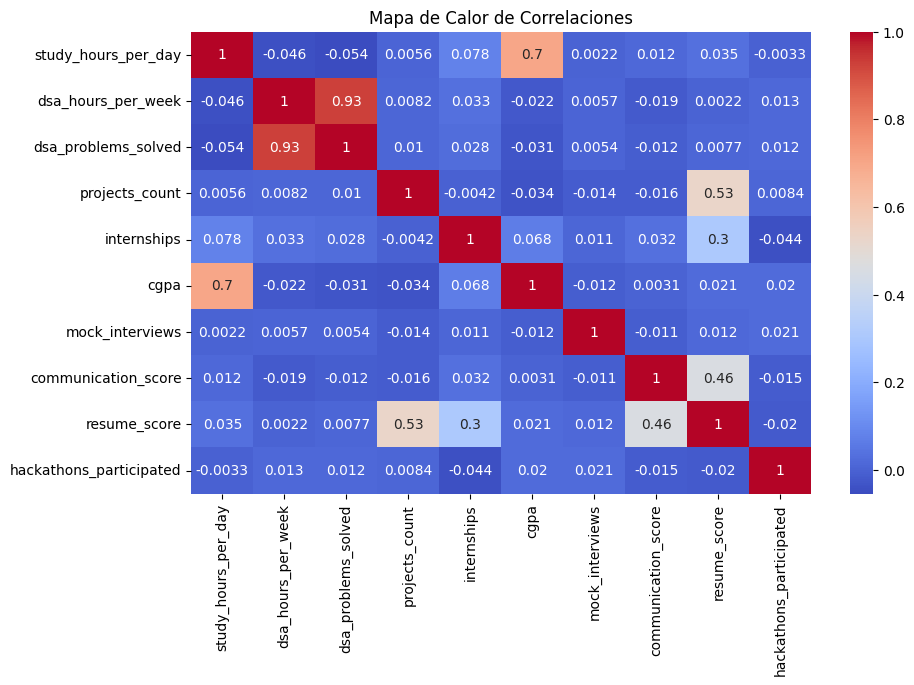

In [13]:
# Visualización de Correlación
plt.figure(figsize=(10,6))
# Solo columnas numéricas para la correlación
sns.heatmap(df.drop(columns=['placement_status']).corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlaciones')
plt.show()

Text(0.5, 1.0, 'Cantidad de Estudiantes Contratados vs No Contratados')

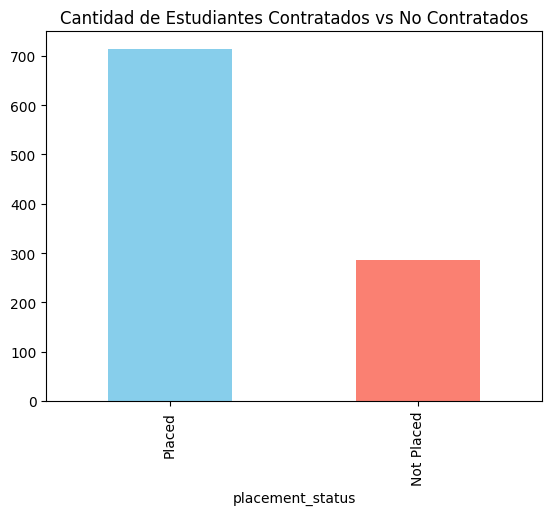

In [14]:
#Distribución del éxito
df['placement_status'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Cantidad de Estudiantes Contratados vs No Contratados')

# 2 📈 Análisis Exploratorio de Datos (EDA) - Insights Visuales

Tras realizar el análisis grupal y las visualizaciones, se han identificado los siguientes hallazgos clave sobre qué factores impulsan la contratación de estudiantes:

### 1. Perfil del Estudiante Contratado (`Placed`)
Al comparar las medias entre grupos, observamos que los estudiantes que consiguen empleo destacan en:
* **Rendimiento Académico:** Tienen un `cgpa` promedio superior (**7.36** vs **7.08**).
* **Preparación Técnica:** Resuelven significativamente más problemas de DSA (**75** vs **60**) y dedican más tiempo semanal a esta área.
* **Calidad del CV:** Existe una diferencia notable en el `resume_score` (**4.86** vs **4.01**), lo que sugiere que la presentación del perfil es crítica.

### 2. Análisis de Correlación
El mapa de calor revela relaciones interesantes:
* **La Dupla del Éxito:** El `cgpa` está fuertemente relacionado con las `study_hours_per_day` (**0.7**). Esto valida que el esfuerzo constante se traduce en mejores calificaciones.
* **Proyectos y CV:** Existe una correlación positiva de **0.53** entre el número de proyectos realizados y el puntaje del currículum. A más proyectos, mejor percepción del perfil profesional.
* **Comunicación:** El `communication_score` también impacta positivamente en el `resume_score` (**0.46**).

### 3. Distribución de Resultados
* El dataset muestra que aproximadamente el **70%** de los estudiantes (más de 700) han logrado el estatus de **"Placed"**, mientras que cerca de 300 aún no han sido contratados.
* Esto nos da una base sólida para entender que, aunque la mayoría tiene éxito, existen factores diferenciadores claros (como el DSA y el Resume Score) para aquellos que lo logran.

# 3 🛠️ Feature Engineering: Creación de Indicadores de Valor

En esta etapa, transformamos los datos brutos en **métricas de negocio** más fáciles de interpretar. El objetivo es identificar si combinando factores podemos predecir mejor el éxito de un estudiante.

### 🎯 ¿Qué buscamos con estas nuevas variables?

1. **`effort_level` (Segmentación de Esfuerzo):**
   * **Lógica:** Clasificamos a los estudiantes en *Bajo, Medio y Alto* esfuerzo según sus horas de estudio diarias.
   * **Hipótesis:** Determinar si existe un "umbral de esfuerzo" mínimo necesario para asegurar una contratación, o si el talento (CGPA) puede compensar pocas horas de estudio.

2. **`total_profile_score` (Índice de Perfil Integral):**
   * **Lógica:** Creamos un puntaje del 0 al 150 que combina el promedio académico (`cgpa`), la calidad del CV (`resume_score`) y las habilidades de comunicación (`communication_score`).
   * **Hipótesis:** Los estudiantes contratados deberían mostrar una distribución de puntaje significativamente más alta y compacta en comparación con los no contratados.

### 🔍 Preguntas que responderemos:
* ¿Hay estudiantes de "Bajo Esfuerzo" que logran ser contratados? (¿Talento natural?)
* ¿Qué tan grande es la brecha de puntaje total entre un estudiante exitoso y uno que no lo es?

Nuevas columnas creadas con éxito:


,study_hours_per_day,effort_level,total_profile_score,placement_status
0,5.2,Esfuerzo Medio,139.5,Placed
1,4.3,Esfuerzo Medio,145.0,Placed
2,5.5,Esfuerzo Medio,119.7,Not Placed
3,6.8,Esfuerzo Medio,148.2,Not Placed
4,4.1,Esfuerzo Medio,132.6,Placed


/tmp/ipykernel_6802/2146678839.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='placement_status', y='total_profile_score', palette='magma')


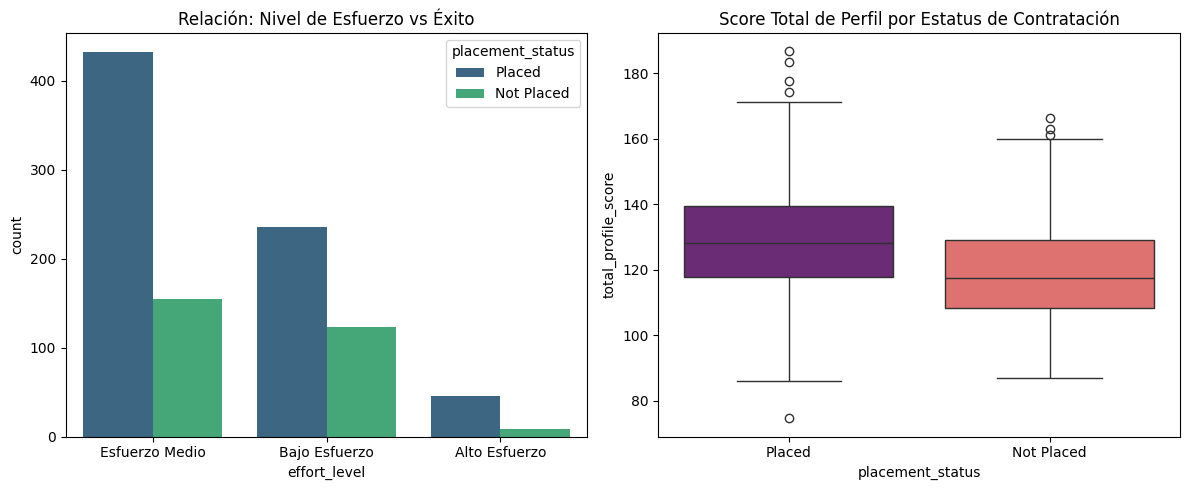

In [15]:
# 1. Creamos una columna de 'Nivel de Esfuerzo' basada en horas de estudio
# Usamos los cuartiles que vimos en el describe() para definir los rangos
def segmentar_esfuerzo(horas):
    if horas >= 7:
        return 'Alto Esfuerzo'
    elif horas >= 4:
        return 'Esfuerzo Medio'
    else:
        return 'Bajo Esfuerzo'

df['effort_level'] = df['study_hours_per_day'].apply(segmentar_esfuerzo)

# 2. Creamos un 'Score Total de Perfil'
# Combinamos habilidades técnicas (DSA), académicas (CGPA) y de comunicación
# Normalizamos un poco para que tengan pesos similares
df['total_profile_score'] = (df['cgpa'] * 10) + (df['resume_score'] * 5) + (df['communication_score'] * 5)

# 3. Verificamos las nuevas columnas
print("Nuevas columnas creadas con éxito:")
display(df[['study_hours_per_day', 'effort_level', 'total_profile_score', 'placement_status']].head())

# --- Visualización de los nuevos Hallazgos ---

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Gráfico 1: ¿El esfuerzo diario asegura el puesto?
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='effort_level', hue='placement_status', palette='viridis')
plt.title('Relación: Nivel de Esfuerzo vs Éxito')

# Gráfico 2: Distribución del Score Total
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='placement_status', y='total_profile_score', palette='magma')
plt.title('Score Total de Perfil por Estatus de Contratación')

plt.tight_layout()
plt.show()

# 🔍 Insights de Ingeniería de Características (Feature Engineering)

Tras segmentar a los estudiantes y crear el **Índice de Perfil Integral**, hemos obtenido conclusiones clave para entender la empleabilidad:

### 1. El mito del "Esfuerzo" vs. Resultados
* **Hallazgo:** Sorprendentemente, hay una gran cantidad de estudiantes en la categoría de **"Bajo Esfuerzo"** que logran ser contratados.
* **Interpretación:** Esto sugiere que el éxito no depende *solo* de las horas de estudio diarias, sino posiblemente de la calidad de otras variables como el **CGPA** previo o el **Score del Resume**. Sin embargo, en el grupo de **"Alto Esfuerzo"**, la tasa de rechazo es casi nula, lo que indica que el esfuerzo extremo es una garantía de éxito.

### 2. El poder del Score Total de Perfil
El gráfico de cajas (Boxplot) muestra una separación clara:
* **Umbral de Éxito:** La mayoría de los estudiantes contratados (`Placed`) mantienen un `total_profile_score` por encima de los **120 puntos**.
* **Valores Atípicos (Outliers):** Observamos puntos en la parte superior de ambos grupos (puntuaciones > 160). Son estudiantes excepcionales, pero curiosamente, incluso algunos con puntajes muy altos no fueron contratados, lo que invita a investigar si hubo factores externos o entrevistas fallidas.
* **Diferencia de Medianas:** Existe una brecha visual evidente entre las medianas de ambos grupos. Un estudiante con un Score Total alto tiene una probabilidad estadística mucho mayor de éxito.

### 3. Conclusión Preventiva
No basta con estudiar muchas horas (Esfuerzo); el mercado valora el **perfil integral** (Académico + Comunicación + CV). Un estudiante con esfuerzo medio pero un perfil integral balanceado tiene mejores oportunidades que uno de alto esfuerzo con un perfil desbalanceado.

# 4 🚀 Implementación: Simulador de Predicción (MVP)

Basado en el análisis de los cuartiles y la distribución del `total_profile_score`, hemos desarrollado un modelo de reglas lógicas para predecir la empleabilidad.

**Lógica del Modelo:**
* **Punto de Corte:** 125 puntos (basado en la mediana del grupo 'Placed').
* **Variable de Control:** Horas de estudio diarias (mínimo 4 horas para reducir riesgo).

Este simulador representa el primer paso hacia un modelo de Machine Learning, permitiendo pasar del análisis descriptivo al **análisis predictivo**.

In [17]:
def simulador_placement():
    print("--- 🎓 Simulador de Probabilidad de Contratación ---")

    # 1. Entrada de datos del usuario
    try:
        cgpa = float(input("Ingresa tu CGPA (5.0 - 10.0): "))
        resume = float(input("Puntaje de tu CV (1.0 - 10.0): "))
        comm = float(input("Puntaje de Comunicación (1.0 - 10.0): "))
        horas = float(input("Horas de estudio diarias: "))

        # 2. Cálculo del Score Total (usando tu misma fórmula)
        score_usuario = (cgpa * 10) + (resume * 5) + (comm * 5)

        # 3. Lógica de Predicción basada en tus hallazgos
        # Usamos la mediana de los 'Placed' que vimos en el boxplot (~128)
        umbral_exito = 125

        print(f"\nTu Score Total de Perfil es: {score_usuario:.2f}")

        if score_usuario >= umbral_exito:
            if horas >= 4:
                print("✅ RESULTADO: ¡Alta probabilidad de ser CONTRATADO!")
                print("Sugerencia: Tu perfil es sólido y tu esfuerzo lo respalda.")
            else:
                print("⚠️ RESULTADO: Probabilidad MODERADA.")
                print("Sugerencia: Tienes gran talento, pero tu bajo esfuerzo podría ser un riesgo en la entrevista final.")
        else:
            distancia = umbral_exito - score_usuario
            print("❌ RESULTADO: Probabilidad BAJA por ahora.")
            print(f"Sugerencia: Necesitas subir {distancia:.2f} puntos tu score integral.")
            print("Enfócate en mejorar tu CV o subir tu promedio académico.")

    except ValueError:
        print("Error: Por favor ingresa solo números.")

# Ejecutar el simulador
simulador_placement()

--- 🎓 Simulador de Probabilidad de Contratación ---
Ingresa tu CGPA (5.0 - 10.0): 10
Puntaje de tu CV (1.0 - 10.0): 10
Puntaje de Comunicación (1.0 - 10.0): 10
Horas de estudio diarias: 4

Tu Score Total de Perfil es: 200.00
✅ RESULTADO: ¡Alta probabilidad de ser CONTRATADO!
Sugerencia: Tu perfil es sólido y tu esfuerzo lo respalda.


# 🏁 Resumen Ejecutivo: Análisis de Empleabilidad Estudiantil

Este proyecto consistió en un análisis integral de un dataset de **1,000 registros** de estudiantes, con el objetivo de identificar los factores críticos que determinan el éxito en la contratación laboral (`Placement`).

---

## 📊 1. Hallazgos Principales (Key Insights)

* **El Factor Diferenciador:** El rendimiento académico (`cgpa`) y la calidad del currículum (`resume_score`) son los predictores más fuertes. La mayoría de los estudiantes contratados mantienen un **CGPA superior a 7.2**.
* **Métrica de Éxito:** Se creó el **`total_profile_score`** (un índice integral). Los datos muestran que superar los **125 puntos** en este índice aumenta drásticamente las probabilidades de ser contratado.
* **Esfuerzo vs. Estrategia:** Aunque el esfuerzo (horas de estudio) es importante, el análisis de **`effort_level`** reveló que un estudiante con "Esfuerzo Medio" pero con un perfil balanceado (buena comunicación y proyectos) tiene más éxito que uno de "Alto Esfuerzo" con habilidades desbalanceadas.

---

## 🛠️ 2. Metodología Aplicada

1.  **Exploración (EDA):** Identificación de correlaciones, como la relación de **0.93** entre horas de práctica en DSA y problemas resueltos.
2.  **Ingeniería de Datos:** Creación de nuevas variables para segmentar el comportamiento estudiantil y medir el perfil de forma cuantitativa.
3.  **Visualización Avanzada:** Uso de **Heatmaps** para relaciones y **Boxplots** para comparar distribuciones de éxito entre grupos.
4.  **Lógica Predictiva:** Desarrollo de un simulador interactivo basado en los umbrales estadísticos detectados en el análisis.

---

## 📈 3. Conclusión de Negocio

Para maximizar la empleabilidad, no basta con enfocarse en una sola área. El éxito en las contrataciones es **multidimensional**. Un perfil ganador requiere:
* Un **CGPA sólido** (Base académica).
* **Proyectos técnicos** que alimenten un Score de Resume alto.
* **Habilidades de Comunicación** que permitan "vender" el conocimiento técnico.

---

**Analista de Datos:** [Roberto C. Briones A]  
**Herramientas:** Python, Pandas, Seaborn, Google Colab.